# Week 10 - Differentiation and its applications in AI

## Motivation

Modern AI learns by tuning millions of parameters.  

The key question:

> *In which direction should we change them to improve performance?*

<div style="display: flex;">
  <div style="flex: 50%; padding: 10px;">
    <p>

**Differentiation provides the answer.**

- Derivatives measure how parameter changes affect the loss  
- They give **local sensitivity → actionable direction**  
- This enables **gradient-based learning**
- Makes high-dimensional optimization feasible
- Powers training of neural networks and most ML models 

#### Content

- Derivatives (definition, computation)  

- Gradients in simple models

- Automatic differentiation
      
- Backpropagation  


  
  </p>
  </div>
  <div style="flex: 50%; padding: 10px;">
    <p><div style="text-align: center;">
<img src="./gradient2.png" width="500" height="600">
</div></p>
  </div>
</div>

## Differentiation in Normed Spaces

#### The small-$o$ and big-$O$ notation

Let $X, Y$ be normed spaces and let $r : X \to Y$.

- We say that
  $$
  r(h) = o(\|h\|) \quad \text{as } h \to 0
  $$
  if
  $$
  \frac{\|r(h)\|}{\|h\|} \to 0 \quad \text{as } h \to 0.
  $$
  This means that $r(h)$ is negligible compared to $\|h\|$.

- We say that
  $$
  r(h) = O(\|h\|)
  $$
  if there exist constants $C > 0$ and $\delta > 0$ such that
  $$
  \|r(h)\| \le C \|h\| \quad \text{whenever } \|h\| < \delta.
  $$
  This means that $r(h)$ grows at most linearly in $\|h\|$.

In particular,
$$
o(\|h\|) \subset O(\|h\|).
$$

#### The Derivative

**Definition:** Let $X$ and $Y$ be normed spaces, and let $f: X \to Y$. Assume that $x \in X$ is such that a neighborhood of $x$ is contained in the domain of $f$.

We say that $f$ is **differentiable at** $x$ if there exists a bounded linear map $\nabla f(x): X \to Y$ such that
$$
f(x + \Delta x) = f(x) + \nabla f(x)\,\Delta x + o(\|\Delta x\|_X)
\quad \text{as } \Delta x \to 0.
$$

- $\nabla f(x)$ is called the **(Fréchet) derivative** of $f$ at $x$. It is also commonly denoted by $df(x)$ or $Df(x)$, and in the one-dimensional case, by $f'(x)$.

- **Interpretation:** $\nabla f(x)$ is the **best linear approximation** of $f$ near $x$, i.e. it describes the first-order behavior of $f$ under small perturbations $\Delta x$.


- In the finite-dimensional setting, for example when $X = \mathbb{R}^n$ and $Y = \mathbb{R}^m$, the derivative $\nabla f(x)$ at any point $x \in \mathbb{R}^n$ can be represented as an $m \times n$ matrix, called the **Jacobian matrix** of $f$.



<div style="display: flex;">
  <div style="flex: 50%; padding: 10px;">
    <p>

#### The Gradient

If $Y = \mathbb{R}$, then at every point $x \in X$, the derivative $\nabla f(x) \in X^*$ is a continuous linear functional.

- Therefore, if $X$ is equipped with an inner product $\langle \cdot, \cdot \rangle$, then by the Riesz representation theorem there exists a vector $\mathrm{grad}\, f(x) \in X$ such that
  $$
  \nabla f(x)\, v = \langle \mathrm{grad}\, f(x), v \rangle.
  $$

- This vector $\mathrm{grad}\, f(x) \in X$ is called the **gradient** of $f$ at $x$.

- Hence, the notion of the gradient depends on the choice of the inner product.

- This observation underlies the **natural gradient** method introduced by Shun'ichi Amari.
  
  </p>
  </div>
  <div style="flex: 50%; padding: 10px;">
    <p><div style="text-align: center;">
<img src="./Amari.png" width="400" height="400">
</div></p>
  </div>
</div>

#### Example

1. Let $T: X \to Y$ be a bounded linear operator. Then $T$ is its own best linear approximation, which immediately implies that
   $$
   \nabla T(x) = T, \quad x \in X.
   $$

2. Let $X = \mathbb{R}^d$, $Y = \mathbb{R}$, and define $f(x) = \|x\|^2 = \langle x, x \rangle$. Then for arbitrary $x, \Delta x \in \mathbb{R}^d$,
   $$
   f(x + \Delta x) = \|x + \Delta x\|^2 
   = \underbrace{\|x\|^2}_{f(x)} 
   + \langle 2x, \Delta x \rangle 
   + \underbrace{\|\Delta x\|^2}_{o(\|\Delta x\|)}.
   $$
   From this expansion, it follows directly that
   $$
   \nabla f(x) = \langle 2x, \cdot \rangle.
   $$

3. Common activation functions and their derivatives:

     
<div style="display: flex;">
  <div style="flex: 50%; padding: 10px;">
    <p>

- **Sigmoid**:
     $$
     \sigma(x) = \frac{1}{1 + e^{-x}}, \quad
     \sigma'(x) = \sigma(x)\big(1 - \sigma(x)\big).
     $$

- **Tanh**:
     $$
     \sigma(x) = \tanh(x), \quad
     \sigma'(x) = 1 - \tanh^2(x).
     $$
  
- **ReLU**:
     $$
     \sigma(x) = \max(0,x), \quad
     \sigma'(x) =
     \begin{cases}
     1, & x > 0, \\
     0, & x \le 0.
     \end{cases}
     $$
  
  </p>
  </div>
  <div style="flex: 50%; padding: 10px;">
    <p><div style="text-align: center;">
<img src="./actfns.png" width="300" height="400">
</div></p>
  </div>
</div>

### Basic Properties

- **Linearity of Differentiation:** Let $f, g : X \to Y$ be differentiable at $x$, and let $\alpha, \beta \in \mathbb{R}$. Then
$$
\nabla (\alpha f + \beta g)(x)
=
\alpha \nabla f(x) + \beta \nabla g(x).
$$

- **Differentiability implies Continuity:** If $f$ is differentiable at $x$, then $f$ is continuous at $x$.
    
    * **The Converse is False:** Continuity does not imply differentiability. E.g. $f(x) = ReLU(x)$ is continuous at $0$, but not differentiable at $0$.


#### Chain Rule

**Theorem (Chain Rule):** Let $X, Y, Z$ be normed spaces. Let $f: X \to Y$ be differentiable at $x$, and let $g: Y \to Z$ be differentiable at $y = f(x)$.

Then the composition $g \circ f$ is differentiable at $x$, and
$$
\nabla (g \circ f)(x)
=
\nabla g(f(x)) \circ \nabla f(x).
$$

**Proof (sketch):**

By the differentiability of $g$ at $f(x)$ and the continuity of $f$ at $x$, we have
$$
g \circ f (x+\Delta x) = g \circ f (x) + \nabla g (f(x))(f(x+\Delta x)-f(x)) + o(\|f(x+\Delta x)-f(x)\|).
$$
Using the differentiability of $f$ at $x$, this can be rewritten as
$$
g \circ f (x+\Delta x) = g \circ f (x) + \nabla g (f(x)) \circ \nabla f (x)\, \Delta x
+ \underbrace{\nabla g (f(x))(o(\|\Delta x\|)) + o(\|f(x+\Delta x)-f(x)\|)}_{\text{Claim: }= o(\|\Delta x\|)}.
$$

Indeed, we can write
$$
\frac{\|\nabla g (f(x))(o(\|\Delta x\|)) + o(\|f(x+\Delta x)-f(x)\|)\|}{\|\Delta x\|}
\le
\|\nabla g (f(x))\| \frac{\|o(\|\Delta x\|)\|}{\|\Delta x\|}
+
\left[
\|\nabla f (x)\| + \frac{\|o(\|\Delta x\|)\|}{\|\Delta x\|}
\right]
\frac{\|o(\|f(x+\Delta x)-f(x)\|)\|}{\|f(x+\Delta x)-f(x)\|}
\to 0, \quad \Delta x \to 0.
$$

## Gradients in simple models

### Regularized Linear Regression


<div style="display: flex;">
  <div style="flex: 50%; padding: 10px;">
  <p>

Let
$$
f_\theta(x) = \langle w, x\rangle + b, \quad
L(\theta) = \frac{1}{2n}\sum_{i=1}^n (f_\theta(x_i) - y_i)^2 + \frac{\lambda}{2}\|w\|^2.
$$

Then
$$
\nabla_w L = \frac{1}{n}\sum_{i=1}^n (f_\theta(x_i) - y_i)x_i + \lambda w, \quad
\partial_b L = \frac{1}{n}\sum_{i=1}^n (f_\theta(x_i) - y_i).
$$

  </p>
  </div>
  <div style="flex: 50%; padding: 10px;">
    <p><div style="text-align: center;">
<img src="./reglin.png" width="500" height="400">
</div></p>
  </div>
</div>

### Logistic Regression


<div style="display: flex;">
  <div style="flex: 50%; padding: 10px;">
  <p>

Let $x \in \mathbb{R}^d$, $y \in \{0,1\}$, and
$$
p_\theta(x) = \sigma(\langle w, x\rangle + b), \quad \sigma(t) = \frac{1}{1+e^{-t}}.
$$

The (per-sample) logistic loss is
$$
\ell(\theta; x,y) = - y \log p_\theta(x) - (1-y)\log(1-p_\theta(x)).
$$

Then
$$
\nabla_w \ell = (p_\theta(x) - y)\, x, \quad
\partial_b \ell = p_\theta(x) - y.
$$

For a dataset $\{(x_i,y_i)\}_{i=1}^n$,
$$
\nabla_w L = \frac{1}{n}\sum_{i=1}^n (p_\theta(x_i) - y_i)x_i, \quad
\partial_b L = \frac{1}{n}\sum_{i=1}^n (p_\theta(x_i) - y_i).
$$

  </p>
  </div>
  <div style="flex: 50%; padding: 10px;">
    <p><div style="text-align: center;">
<img src="./logistic.png" width="500" height="400">
</div></p>
  </div>
</div>

### Single layer neural network

<div style="display: flex;">
  <div style="flex: 50%; padding: 10px;">
  <p>

Let
$$
f_\theta(x) = \sigma(Wx + b),
$$
where $W \in \mathbb{R}^{m \times d}$, $b \in \mathbb{R}^m$, and $\sigma$ acts componentwise.

Let the loss be $\ell(f_\theta(x), y)$. Denote
$$
z = Wx + b, \quad a = \sigma(z).
$$

By the chain rule,
$$
\nabla_W \ell = \left( \nabla_a \ell \odot \sigma'(z) \right) x^\top, \quad
\nabla_b \ell = \nabla_a \ell \odot \sigma'(z),
$$
where $\odot$ denotes elementwise multiplication.

  </p>
  </div>
  <div style="flex: 50%; padding: 10px;">
    <p><div style="text-align: center;">
<img src="./single_layer.png" width="500" height="400">
</div></p>
  </div>
</div>


### Two layer neural network


<div style="display: flex;">
  <div style="flex: 50%; padding: 10px;">
  <p>

Let
$$
f_\theta(x) = W_2 \sigma(W_1 x + b_1) + b_2.
$$

Set
$$
z_1 = W_1 x + b_1, \quad a_1 = \sigma(z_1), \quad z_2 = W_2 a_1 + b_2.
$$

Let the loss be $\ell(z_2, y)$. Define
$$
\delta_2 = \nabla_{z_2} \ell, \quad
\delta_1 = (W_2^\top \delta_2) \odot \sigma'(z_1).
$$

Then
$$
\nabla_{W_2} \ell = \delta_2 a_1^\top, \quad
\nabla_{b_2} \ell = \delta_2,
$$
$$
\nabla_{W_1} \ell = \delta_1 x^\top, \quad
\nabla_{b_1} \ell = \delta_1.
$$

  </p>
  </div>
  <div style="flex: 50%; padding: 10px;">
    <p><div style="text-align: center;">
<img src="./two_layer.png" width="500" height="400">
</div></p>
  </div>
</div>

### Finite Increment Formula

**Theorem (Finite Increment Formula):** Let $X$ and $Y$ be normed spaces, and let $f: X \to Y$. Let $x, y \in X$, and assume that the closed segment
$$
\overline{I} = \{x + t (y - x) : t \in [0,1]\}
$$
is contained in the domain of $f$.

Assume that:
- $f$ is continuous on $\overline{I}$,  
- $f$ is differentiable at every point of the open segment
$$
I = \{x + t (y - x) : t \in (0,1)\}.
$$

Then
$$
\| f(x) - f(y) \|
\le
\sup_{z \in I} \| \nabla f(z) \| \, \| x - y \|.
$$

**Corollary:** Suppose that $f$ is differentiable on a convex domain $U \subset X$ and that its derivative is bounded. Then $f : U \to Y$ is Lipschitz continuous:
$$
\|f(x) - f(y)\| \le L \|x - y\|,
$$
with Lipschitz constant
$$
L = \sup_{z \in U} \|\nabla f(z)\|.
$$

**Example:** Consider logistic regression. Fix $x \in \mathbb{R}^d$ and define
$$
p_w(x) = \sigma(\langle w, x\rangle), \quad \sigma(t) = \frac{1}{1+e^{-t}}.
$$
Then
$$
\nabla_w p_w(x) = \sigma'(\langle w, x\rangle)\, x.
$$
Using the identity $\sigma'(t) = \sigma(t)(1 - \sigma(t))$ and the inequality between the arithmetic and geometric means, we obtain
$$
\sigma'(t) = \sigma(t)(1 - \sigma(t)) \le \frac{1}{4}.
$$
Hence,
$$
\sup_{w \in \mathbb{R}^d} \|\nabla_w p_w(x)\| \le \frac{\|x\|}{4}.
$$
By the corollary, it follows that
$$
|p_{w_1}(x) - p_{w_2}(x)| \le \frac{\|x\|}{4} \|w_1 - w_2\|.
$$

### Higher-Order Derivatives

Higher-order derivatives are defined inductively.

Let $f: X \to Y$. We say that $f$ is $m$-times differentiable at $x$ if:
- $f$ is $(m-1)$-times differentiable in a neighborhood of $x$, and  
- the $(m-1)$-th derivative is differentiable at $x$.

The $m$-th derivative is then a multilinear map:
$$
\nabla^m f(x) \in \mathrm{Lin}(\underbrace{X, \ldots, X}_{m}, Y).
$$

**Theorem (Symmetry of Higher-Order Derivatives):** If $f: X \to Y$ is $m$-times differentiable at $x$, then
$$
\nabla^m f(x):\underbrace{X\times\ldots\times X}_{m}\to X
$$
is a **symmetric $m$-linear map**.

**Remark:**
- In the case $m = 2$, if $X = \mathbb{R}^n$, $Y = \mathbb{R}$, and $X$ is equipped with an inner product $\langle \cdot, \cdot \rangle$, then there exists an $n \times n$ matrix $H(x)$ such that
  $$
  \nabla^2 f(x)(u,v) = \langle u, H(x) v \rangle.
  $$

- This matrix $H(x)$ is called the **Hessian** of $f$ at the point $x$.

- Locally, the function $f$ admits the second-order expansion
  $$
  f(x+\Delta x) = f(x) + \nabla f(x)\, \Delta x + \frac{1}{2} \langle \Delta x, H(x)\Delta x \rangle + o(\|\Delta x\|^2).
  $$

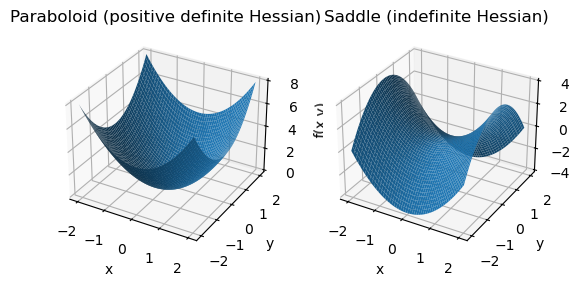

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Grid
x = np.linspace(-2, 2, 200)
y = np.linspace(-2, 2, 200)
X, Y = np.meshgrid(x, y)

# Quadratic forms
Z_paraboloid = X**2 + Y**2      # positive definite Hessian
Z_saddle = X**2 - Y**2          # indefinite Hessian

fig = plt.figure()
ax1 = fig.add_subplot(121, projection='3d')
ax2 = fig.add_subplot(122, projection='3d')

# Paraboloid
ax1.plot_surface(X, Y, Z_paraboloid)
ax1.set_title("Paraboloid (positive definite Hessian)")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("f(x,y)")

# Saddle
ax2.plot_surface(X, Y, Z_saddle)
ax2.set_title("Saddle (indefinite Hessian)")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_zlabel("f(x,y)")

plt.show()

## Automatic Differentiation (AD)

>Let $f : \mathbb{R}^n \to \mathbb{R}^m$ be a differentiable function defined on an open set $U \subset \mathbb{R}^n$.  
Our goal is to compute its derivative (Jacobian) $Df(x)$ in a way that is both 
>>* **computationally efficient**
>>* and **numerically stable**.


### Classical approaches and their limitations

1. Manual differentiation
    - **Method:** One derives $Df$ analytically and then implements it.
      
    - **Limitation:** Not stable under model changes. In modern ML, $f$ is often defined implicitly by code (e.g. a neural network), so recomputing derivatives manually is not scalable.


2. Symbolic differentiation
    - **Method:** Treat $f$ as a symbolic expression and compute $Df$ algebraically.
  
    -**Limitation:**
      * Requires an explicit formula for $f$ (not just code).
        
      *  Suffers from **expression swell**: intermediate expressions grow combinatorially.
  
      *   Produces mathematically correct but computationally inefficient representations.

3. Numerical differentiation
    - **Method:** Approximate derivatives via finite differences:
      $$
        \partial_i f(x) \approx \frac{f(x + h e_i) - f(x)}{h}.
      $$

    - **Limitation:**
       * Only approximate.

       * Sensitive to floating point errors.
     
       * Requires $O(n)$ evaluations for gradients, which is prohibitive in high dimension.
     
#### Summary

| Method                   | Accuracy | Computational Cost | Suitability |
|--------------------------|----------|-------------------|--------------|
| Manual Differentiation   | Exact    | High (manual work) | Simple functions |
| Symbolic Differentiation | Exact    | High (expression swell) | Closed-form expressions |
| Numerical Differentiation | Approximate | Low (depends on step size) | Small-scale problems |
| **Automatic Differentiation** | **Exact (machine precision)** | **Efficient (depends on mode)** | **Most general & scalable** |


#### AD: How it works?

* Automatic differentiation (AD) is best understood as a **systematic implementation of the chain rule on a computational decomposition of $f$**.

* Any function computed by a program can be written as a composition of elementary maps:
$$
f = f_L \circ f_{L-1} \circ \cdots \circ f_1,
$$
where each $f_k$ is a simple operation (affine map, nonlinearity, etc.).

* Define intermediate states:
$$
x_0 = x, \quad x_k = f_k(x_{k-1}), \quad f(x) = x_L.
$$

* By repeated application of the chain rule,
$$
Df(x) = Df_L(x_{L-1}) \cdots Df_1(x_0).
$$

* AD performs **local differentiation at each node** and propagates derivatives globally via the chain rule.

>**AD computes this product efficiently without ever forming full Jacobians explicitly.**


<p><div style="text-align: center;">
<img src="./ForwardBackwardAD.png" width="1000" height="600">
</div></p>

### Why reverse mode dominates in machine learning

In ML, typically:
$$
f : \mathbb{R}^n \to \mathbb{R}, \quad n \gg 1
$$
(e.g. millions of parameters, scalar loss).

- Forward mode: $O(n)$ passes  
- Reverse mode: **1 forward + 1 backward pass**

Hence reverse mode computes the full gradient in essentially the cost of evaluating $f$.


### Conceptual summary

Automatic differentiation is:

- A **numerically exact** method (up to floating point precision)  
- A **computational realization of the chain rule**  
- A way to evaluate **linear maps (derivatives) without forming them explicitly**  

Mathematically, AD turns the abstract object
$$
Df(x)
$$
into an efficiently computable operator acting on vectors, which is precisely what optimization algorithms require.

### Worked Example: composition with a multivariate intermediate layer

Consider
$$
f(x) = (f_2 \circ f_1)(x),
$$
where
$$
f_1 : \mathbb{R} \to \mathbb{R}^2, \quad f_1(x) = (x, x^2),
$$
and
$$
f_2 : \mathbb{R}^2 \to \mathbb{R}, \quad f_2(u,v) = \sigma(u+v), \quad \sigma(t)=\frac{1}{1+e^{-t}}.
$$

Then
$$
f(x) = \sigma(x + x^2),
$$
which corresponds to a simple “feature map + neuron” model.

<div style="display: flex;">

  <div style="flex: 1; padding: 10px;">

### Forward mode AD

Propagate $(x, \dot{x})$ with $\dot{x}=1$.

1. First layer:
   $$
   (u,v) = (x, x^2), \quad (\dot{u}, \dot{v}) = (1, 2x).
   $$

2. Second layer:
   $$
   y = \sigma(u+v), \quad \dot{y} = \sigma'(u+v)\,(\dot{u}+\dot{v}).
   $$

Substitute:
$$
\dot{y} = \sigma'(x+x^2)(1+2x).
$$

Thus
$$
f'(x) = \sigma'(x+x^2)(1+2x).
$$

  </div>

  <div style="flex: 1; padding: 10px;">

### Reverse mode AD (backpropagation)

1. Forward pass:
   $$
   (u,v) = (x, x^2), \quad y = \sigma(u+v).
   $$

2. Initialize:
   $$
   \bar{y} = 1.
   $$

3. Backward through $f_2$:
   $$
   \bar{u} = \sigma'(u+v), \quad \bar{v} = \sigma'(u+v).
   $$

4. Backward through $f_1$:
   $$
   \bar{x} = \bar{u}\cdot 1 + \bar{v}\cdot 2x.
   $$

Substitute:
$$
\bar{x} = \sigma'(x+x^2)(1+2x).
$$

Thus
$$
f'(x) = \bar{x}.
$$

  </div>

</div>

### Numerical Example

#### 1. Mixed Partial Derivatives, Young's Theorem

In this example, we present a Python function that demonstrates the equality  
$$ \frac{\partial^2 f}{\partial x\partial y} = \frac{\partial^2 f}{\partial y\partial x} $$  
for any twice continuously differentiable function $f:\mathbb{R}^2\to\mathbb{R}$.

In [3]:
import autograd.numpy as np
from autograd import grad

def check_young(f):
    """
    Function to test the equality of mixed partial derivatives:
        ∂²f / ∂x∂y = ∂²f / ∂y∂x
    for a given twice continuously differentiable function f: R² → R.
    
    Parameters:
    f : function
        A scalar-valued function of two variables (x, y).
    
    Returns:
    young : function
        A function that computes the difference between the mixed partial derivatives.
        It should return zero for all inputs if Young's theorem holds.
    """

    # Compute first-order partial derivatives
    dfdx = grad(f, 0)  # ∂f / ∂x
    dfdy = grad(f, 1)  # ∂f / ∂y

    # Compute second-order mixed partial derivatives
    d2fdxdy = grad(dfdx, 1)  # ∂²f / ∂x∂y
    d2fdydx = grad(dfdy, 0)  # ∂²f / ∂y∂x

    # Define a function that returns the difference between the mixed partials
    def young(x, y):
        return d2fdydx(x, y) - d2fdxdy(x, y)
    
    return young

In [4]:
# Define a sample function of two variables
f = lambda x, y: x**2.0 + np.sin(x**3.0 + y**3.4) + x + y

# Generate 10 random points in the domain
x_samples = np.random.rand(10)
y_samples = np.random.rand(10)

# Create the mixed partial derivative checker
checker = check_young(f)

# Compute the differences at each sample point
# The values should be very close to zero if Young's theorem holds
differences = [checker(xi, yi) for xi, yi in zip(x_samples, y_samples)]
print(differences)

[5.551115123125783e-17, 0.0, 0.0, 1.6940658945086007e-21, 0.0, 0.0, 0.0, 0.0, 0.0, -3.469446951953614e-18]


#### 2. Accelerating Root Finding  

The `fsolve` function from SciPy allows us to optionally provide the derivative (Jacobian) of the function $f$ in the equation $f(x) = 0$. Supplying this derivative can significantly reduce the number of function evaluations needed to achieve a given accuracy.  

In the following example, we solve the system of equations  
\begin{align}
x_2 - 3x_1 (x_1^2 - 1) &= 0 \\
0.25 x_1^2 + x_2^2 - 1 &= 0
\end{align}  
both with and without using `autograd` to compute the Jacobian.


In [5]:
from scipy.optimize import fsolve
from autograd import jacobian
import autograd.numpy as np  # Ensure compatibility with autograd

# Define the system of equations
def system(x):
    return np.array([
        x[1] - 3 * x[0] * (x[0]**2 - 1),  # First equation
        0.25 * x[0]**2 + x[1]**2 - 1      # Second equation
    ])

# Initial guess for the solver
x0 = np.array([0.5, 0.5])

# Solve without providing the Jacobian
solution, info, flag, msg = fsolve(system, x0, full_output=True)

print("Solution without Jacobian:", solution)
print("Number of function evaluations:", info['nfev'])

# Compute the Jacobian using autograd
jacobian_matrix = jacobian(system)

# Solve with the Jacobian provided
solution, info, flag, msg = fsolve(system, x0, fprime=jacobian_matrix, full_output=True)

print("Solution with Jacobian:", solution)
print("Number of function evaluations:", info['nfev'])

Solution without Jacobian: [1.11694147 0.82952422]
Number of function evaluations: 21
Solution with Jacobian: [1.11694147 0.82952422]
Number of function evaluations: 15


## Backpropagation as a special case of Automatic Differentiation

Backpropagation is a **special case of reverse-mode automatic differentiation (AD)** applied to computational graphs with a layered structure, such as neural networks.

In general, reverse-mode AD computes gradients of a scalar-valued function
$
L = f(x_1, \dots, x_n)
$
by traversing the computational graph backwards and applying the chain rule locally at each node.

Neural networks impose a **specific structure on this graph**:
- nodes correspond to layers,
- edges correspond to linear and nonlinear transformations,
- parameters appear as matrices and biases.

Thus, backpropagation is simply reverse-mode AD specialized to this structured, parameterized graph.

---

### Matrix formulation of backward mode AD

Consider a standard layer:
$
z = W x + b, \quad a = \sigma(z)
$

Let the upstream gradient be:
$
\bar{a} = \frac{\partial L}{\partial a}.
$

#### Nonlinearity step
Elementwise chain rule:
$
\bar{z} = \bar{a} \odot \sigma'(z)
$

#### Linear layer step
Using matrix calculus:
$
z = W x + b
$

Gradients propagate as:
$
\bar{x} = W^\top \bar{z}
$

Parameter gradients:
$
\bar{W} = \bar{z} \, x^\top
$
$
\bar{b} = \bar{z}
$

---

### Key insight

Backward-mode AD in matrix form consists of repeated applications of:

- **vector–Jacobian products (VJP)** in general AD:
  $
  \bar{x} = \bar{y} \, \frac{\partial y}{\partial x}
  $

- In neural networks, these reduce to:
  - matrix transposes ($W^\top$),
  - outer products ($\bar{z} x^\top$),
  - elementwise Hadamard products ($\odot$).

---

### Summary

Backpropagation is:
- reverse-mode automatic differentiation restricted to neural network computation graphs,
- implemented efficiently using linear algebra operations (transpose, outer product, Hadamard product),
- avoiding explicit construction of Jacobians by using vector–Jacobian products.

## Shun'ichi Amari – Short Biography

![Shun'ichi Amari](./Amari.jpg)

### Basic information
Shun'ichi Amari (甘利 俊一), born in 1936 in Tokyo, Japan, is a Japanese engineer and neuroscientist.  
He is widely recognized as a pioneer of **information geometry** and contributions to **artificial intelligence**.

---

### Education
- 1958: BSc in Mathematical Engineering, University of Tokyo  
- 1960: MSc – *Topological and Information-Theoretical Foundation of Diakoptics and Codiakoptics*  
- 1963: Doctor of Engineering – *Diakoptics of Information Spaces*  

---

### Career
- Published more than **200 peer-reviewed papers**
- Foundational developer of **information geometry**
- Visiting professor at multiple universities
- Leading figure in mathematical neuroscience

---

### Contributions to Artificial Intelligence

#### Early neural network research
- 1967: Proposed early artificial neural network models trained with **stochastic gradient descent (SGD)**
- 1967: With H. Saito, reported an early **multilayer perceptron (MLP)** trained via SGD
- Anticipated key ideas behind **backpropagation**

#### Recurrent and associative networks
- 1972: With Kaoru Nakano, developed early **recurrent neural network (RNN)** models
- 1972: Introduced the **Amari network**, an early form of energy-based recurrent system  
- This work preceded and anticipated the **Hopfield network** (1982); Amari’s formulation is now often seen as an independent precursor to Hopfield’s model

#### Optimization and learning theory
- Introduced the **natural gradient method**, a geometrically motivated optimization technique for neural network training  
- This approach redefines gradient descent using the Riemannian structure of parameter space, improving learning efficiency in probabilistic models

---

### Later positions
- RIKEN Brain Science Institute
- Vice-president and director roles in neuroscience and information systems groups
- Leader of the Mathematical Neuroscience Laboratory

---

### Awards
- IEEE Emanuel R. Piore Award (1997)

---

### Significance
Amari is considered a foundational figure linking:
- information geometry
- neural computation
- early deep learning theory
- geometric approaches to learning algorithms (natural gradient)